# Diffusion Kernel Exploration

Systematic exploration of three ways to use the diffusion kernel K_t = exp(−t · L) for spectral clustering with ALC.

Based on Kondor & Lafferty (2002), *Diffusion Kernels on Graphs and Other Discrete Input Spaces*.

| Section | Content |
|---------|--------|
| 1 | Setup and data generation |
| 2 | Core functions: `build_laplacian`, `compute_diffusion_kernel` |
| 3 | Option A — K_t as new affinity; Option B — weighted eigenvectors; Option C — K_t direct to ALC |
| 4 | Baseline (no diffusion) |
| 5 | Experiment sweep |
| 6 | Analysis and visualisation |
| 7 | Summary and interpretation |

---
## Section 1 — Setup and Data Generation

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import numpy as np
import scipy.linalg
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import adjusted_rand_score

from clustering.spectral import dist_mat, knn_affinity
from clustering.alc import ALCAdapter
from data.generators import make_blobs_convex, make_two_moons, make_rings

%matplotlib inline
plt.rcParams['figure.dpi'] = 100


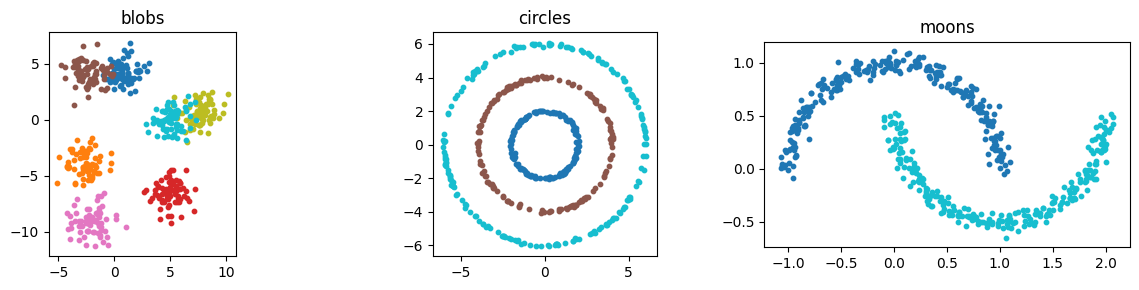

In [2]:
SEED = 0

# Seven Gaussian blobs — 2-D for visualisation
X_blobs,   y_blobs   = make_blobs_convex(N=500, num_clusters=7, n_features=5000,  seed=SEED)
# Three concentric circles
X_circles, y_circles = make_rings(n_points=500, n_circles=3,   noise_std=0.05, seed=SEED)
# Two moons
X_moons,   y_moons   = make_two_moons(n_samples=500, noise=0.05, seed=SEED)

dataset_registry = [
    {
        "name":       "blobs",
        "X":          X_blobs,
        "y":          y_blobs,
        "n_clusters": 7,
        "k_values":   [10, 30],
        "sigma":      10,
        "t_values":   [1, 3, 5, 10],
        "r_values":   [7, 9, 15, 25],
        "lap_types":  ["unnorm", "sym", "rw"],
    },
    {
        "name":       "circles",
        "X":          X_circles,
        "y":          y_circles,
        "n_clusters": 3,
        "k_values":   [len(X_circles) - 1, 10],
        "sigma":      0.5,
        "t_values":   [1, 3, 5, 10],
        "r_values":   [3, 5, 10, 25],
        "lap_types":  ["unnorm", "sym", "rw"],
    },
    {
        "name":       "moons",
        "X":          X_moons,
        "y":          y_moons,
        "n_clusters": 2,
        "k_values":   [len(X_moons) - 1, 10],
        "sigma":      0.1,
        "t_values":   [1, 3, 5, 10],
        "r_values":   [2, 4, 10, 25],
        "lap_types":  ["unnorm", "sym", "rw"],
    },
]

fig, axes = plt.subplots(1, 3, figsize=(12, 3))
for ax, ds in zip(axes, dataset_registry):
    X, y = ds["X"], ds["y"]
    for i, lbl in enumerate(np.unique(y)):
        ax.scatter(X[y == lbl, 0], X[y == lbl, 1], s=10,
                   c=[plt.cm.tab10(i / max(len(np.unique(y)) - 1, 1))])
    ax.set_title(ds["name"])
    ax.set_aspect("equal")
plt.tight_layout()
plt.show()


---
## Section 2 — Core Functions

### `build_laplacian`

Builds one of three Laplacian formulations from an affinity matrix A:

- **`unnorm`**: L = D − A (unnormalised). Symmetric and PSD — valid diffusion kernel.
- **`sym`**: L = I − D^{−1/2} A D^{−1/2} (symmetric normalised). Symmetric and PSD.
- **`rw`**: L = I − D^{−1} A (random-walk normalised). **Not symmetric** — included for comparison only. K_t from L_rw is not guaranteed symmetric.

### `compute_diffusion_kernel`

Computes K_t = exp(−t · L) via eigendecomposition:

1. Decompose L = U Λ U^T (or U Λ U^{−1} for L_rw).
2. Apply exp(−t · λ_j) to each eigenvalue.
3. Reconstruct: K_t = U · diag(exp(−t · λ)) · U^T.

For L_rw, `scipy.linalg.eig` is used (non-symmetric), eigenvalues sorted ascending, real parts taken.

In [3]:
def build_laplacian(A, laplacian_type):
    """
    Build a graph Laplacian from affinity matrix A.

    Parameters
    ----------
    A : (n, n) ndarray
        Symmetric non-negative affinity matrix.
    laplacian_type : {"unnorm", "sym", "rw"}
        Laplacian formulation to use.

    Returns
    -------
    L : (n, n) ndarray
    d : (n,) ndarray  — degree vector
    """
    n = A.shape[0]
    d = A.sum(axis=1)
    I = np.eye(n)

    if laplacian_type == "unnorm":
        D = np.diag(d)
        L = D - A

    elif laplacian_type == "sym":
        D_inv_sqrt = np.diag(1.0 / np.sqrt(d))
        L = I - D_inv_sqrt @ A @ D_inv_sqrt

    elif laplacian_type == "rw":
        D_inv = np.diag(1.0 / d)
        L = I - D_inv @ A

    else:
        raise ValueError(f"Unknown laplacian_type '{laplacian_type}'. Use 'unnorm', 'sym', or 'rw'.")

    return L, d


In [4]:
def compute_diffusion_kernel(L, t, laplacian_type):
    """
    Compute the diffusion kernel K_t = exp(−t · L) via eigendecomposition.

    For symmetric Laplacians ('unnorm', 'sym') uses scipy.linalg.eigh.
    For the non-symmetric random-walk Laplacian ('rw') uses scipy.linalg.eig,
    sorts eigenvalues in ascending order, and takes real parts.

    Parameters
    ----------
    L : (n, n) ndarray
    t : float  — diffusion time (t > 0)
    laplacian_type : str — passed through to select solver

    Returns
    -------
    K_t        : (n, n) ndarray
    eig_vals   : (n,) ndarray  ascending real eigenvalues
    eig_vecs   : (n, n) ndarray  corresponding eigenvectors (columns)
    """
    if laplacian_type in ("unnorm", "sym"):
        # eigh assumes symmetry and returns real, ascending eigenvalues
        eig_vals, eig_vecs = scipy.linalg.eigh(L)
        diffused = np.exp(-t * eig_vals)
        K_t = eig_vecs @ np.diag(diffused) @ eig_vecs.T

    elif laplacian_type == "rw":
        # eig handles non-symmetric matrices; returns complex in general
        eig_vals_raw, eig_vecs_raw = scipy.linalg.eig(L)
        # Sort ascending by real part
        order    = np.argsort(eig_vals_raw.real)
        eig_vals = eig_vals_raw[order].real
        eig_vecs = eig_vecs_raw[:, order].real
        diffused = np.exp(-t * eig_vals)
        # Reconstruct via U diag(exp) U^{-1}
        try:
            U_inv = np.linalg.inv(eig_vecs)
        except np.linalg.LinAlgError:
            U_inv = np.linalg.pinv(eig_vecs)
        K_t = eig_vecs @ np.diag(diffused) @ U_inv

    else:
        raise ValueError(f"Unknown laplacian_type '{laplacian_type}'.")

    return K_t, eig_vals, eig_vecs


---
## Section 3 — The Three Options

**Option A** — treat K_t as a brand-new affinity matrix, build the graph Laplacians from it, and embed via its eigenvectors.

**Option B** — use the eigenvectors of the original Laplacian L, but rescale each coordinate j by exp(−t · λ_j). Analogous to diffusion maps.

**Option C** — pass K_t directly to ALC. Because `ALCAdapter.fit_predict` calls `np.corrcoef(X)` internally, ALC receives the *correlation matrix of K_t's rows* — i.e. it measures whether two points share similar diffusion profiles across the graph. No eigenvector extraction; no rank parameter r.

In [5]:
def option_a_new_affinity(X, k, sigma, laplacian_type, t, r, seed=6):
    """
    Option A: diffuse the affinity through K_t, then re-enter the
    standard spectral pipeline treating K_t as a new affinity.

    The SAME laplacian_type governs both stages:

      Baseline:  A --> L  --> eigenvectors --> ALC
      Option A:  A --> K_t --> L' --> eigenvectors --> ALC

    where L and L' are of the same type.

    Note: at t = 0, K_t = I (identity), so L' is the Laplacian of a
    degenerate graph. Option A does NOT recover the baseline at t = 0.
    """
    np.random.seed(seed)
    n = X.shape[0]
    I = np.eye(n)

    # Step 1-2: distances and k-NN affinity
    D_mat  = dist_mat(X)
    A      = knn_affinity(D_mat, k=k, sigma=sigma)

    # Step 3: first Laplacian from A
    L, _ = build_laplacian(A, laplacian_type)

    # Step 4: diffusion kernel K_t = exp(-t * L)
    K_t, _, _ = compute_diffusion_kernel(L, t, laplacian_type)

    # For L_rw: symmetrise K_t and log if asymmetry is significant
    if laplacian_type == "rw":
        asym_norm = np.linalg.norm(K_t - K_t.T, "fro") / (np.linalg.norm(K_t, "fro") + 1e-12)
        if asym_norm > 1e-6:
            print(f"  [Option A, rw, t={t}] Symmetrising K_t "
                  f"(relative asymmetry = {asym_norm:.2e})")
        K_t = (K_t + K_t.T) / 2.0

    # Step 5: make K_t a valid affinity — zero diagonal, clip negatives
    np.fill_diagonal(K_t, 0.0)
    K_t = np.maximum(K_t, 0.0)

    # Step 6: second Laplacian L' from K_t using the SAME laplacian_type
    d_new = K_t.sum(axis=1)
    if laplacian_type == "unnorm":
        D_new  = np.diag(d_new)
        L_new  = D_new - K_t
    elif laplacian_type == "sym":
        D_new_inv_sqrt = np.diag(1.0 / np.sqrt(d_new + 1e-12))
        L_new = I - D_new_inv_sqrt @ K_t @ D_new_inv_sqrt
    elif laplacian_type == "rw":
        D_new_inv = np.diag(1.0 / (d_new + 1e-12))
        L_new = I - D_new_inv @ K_t

    # Step 7: eigendecompose L_new
    if laplacian_type in ("unnorm", "sym"):
        eig_vals_new, eig_vecs_new = scipy.linalg.eigh(L_new)
    else:  # rw
        ev_raw, evec_raw = scipy.linalg.eig(L_new)
        order            = np.argsort(ev_raw.real)
        eig_vecs_new     = evec_raw[:, order].real

    U = eig_vecs_new[:, :r]

    # Step 8: Ng-Jordan-Weiss row normalisation for sym only
    if laplacian_type == "sym":
        row_norms = np.linalg.norm(U, axis=1, keepdims=True)
        U = U / np.maximum(row_norms, 1e-12)

    # Step 9: cluster
    alc    = ALCAdapter()
    labels = alc.fit_predict(U, cn=None)
    return labels


In [6]:
# --- Option A Validation ---
# Uses moons (small n=200) for speed.

X_val, y_val = X_moons, y_moons
k_val, sigma_val = 10000, 0.1
lap_val = "sym"
n_val   = X_val.shape[0]

# 1. t=0 check: K_t = exp(0) = I  -->  K_t after zeroing diagonal is all zeros
#    L' is the Laplacian of the zero matrix (degenerate). NOT the baseline.
D_val = dist_mat(X_val)
A_val = knn_affinity(D_val, k=k_val, sigma=sigma_val)
L_val, _ = build_laplacian(A_val, lap_val)
K0, _, _ = compute_diffusion_kernel(L_val, t=0, laplacian_type=lap_val)
np.fill_diagonal(K0, 0.0)
print("t=0 check:")
print(f"  K_t (before diag zero) close to identity? {np.allclose(K0 + np.eye(n_val), np.eye(n_val) * 2, atol=1e-6)}")
print(f"  K_t after zeroing diagonal — all zeros? {np.allclose(K0, 0)}")
print(f"  (Option A at t=0 is degenerate — does NOT reproduce baseline)\n")

# 2. Small t: K_t ≈ I - t*L, so affinity is close to A (after zeroing diag)
K_small, _, _ = compute_diffusion_kernel(L_val, t=0.01, laplacian_type=lap_val)
np.fill_diagonal(K_small, 0.0)
K_small = np.maximum(K_small, 0.0)
print(f"t=0.01 check: max entry of K_t = {K_small.max():.4f}  "
      f"(close to original A max = {A_val.max():.4f}?)\n")

# 3. PSD check on L_new for each Laplacian type
print("L_new PSD check (all eigenvalues >= 0):")
for lap in ["unnorm", "sym", "rw"]:
    K_t_psd, _, _ = compute_diffusion_kernel(L_val, t=1.0, laplacian_type=lap)
    if lap == "rw":
        K_t_psd = (K_t_psd + K_t_psd.T) / 2.0
    np.fill_diagonal(K_t_psd, 0.0)
    K_t_psd = np.maximum(K_t_psd, 0.0)
    d_psd   = K_t_psd.sum(axis=1)
    I_psd   = np.eye(n_val)
    if lap == "unnorm":
        L_new_psd = np.diag(d_psd) - K_t_psd
    elif lap == "sym":
        Disq = np.diag(1.0 / np.sqrt(d_psd + 1e-12))
        L_new_psd = I_psd - Disq @ K_t_psd @ Disq
    else:
        L_new_psd = I_psd - np.diag(1.0 / (d_psd + 1e-12)) @ K_t_psd
    min_eig = np.linalg.eigvalsh(L_new_psd).min()
    psd_ok  = min_eig >= -1e-8
    print(f"  L_{lap}: min eigenvalue = {min_eig:.2e}  -->  PSD? {psd_ok}")


t=0 check:
  K_t (before diag zero) close to identity? False
  K_t after zeroing diagonal — all zeros? True
  (Option A at t=0 is degenerate — does NOT reproduce baseline)

t=0.01 check: max entry of K_t = 0.0017  (close to original A max = 0.9999?)

L_new PSD check (all eigenvalues >= 0):
  L_unnorm: min eigenvalue = 7.29e-16  -->  PSD? True
  L_sym: min eigenvalue = 1.62e-12  -->  PSD? True
  L_rw: min eigenvalue = -4.20e-03  -->  PSD? False


In [7]:
def option_b_eigenvector_embedding(X, k, sigma, laplacian_type, t, r, seed=6):
    """
    Option B: original eigenvectors of L, weighted by exp(−t · λ_j).

    The eigenvectors are identical to those used in baseline spectral
    clustering; only the coordinate scaling changes with t.
    """
    np.random.seed(seed)
    D_mat = dist_mat(X)
    A     = knn_affinity(D_mat, k=k, sigma=sigma)
    L, _  = build_laplacian(A, laplacian_type)

    if laplacian_type in ("unnorm", "sym"):
        eig_vals, eig_vecs = scipy.linalg.eigh(L)
    else:  # rw — non-symmetric
        eig_vals_raw, eig_vecs_raw = scipy.linalg.eig(L)
        order    = np.argsort(eig_vals_raw.real)
        eig_vals = eig_vals_raw[order].real
        eig_vecs = eig_vecs_raw[:, order].real

    U = eig_vecs[:, :r]

    # Ng-Jordan-Weiss row normalisation for symmetric Laplacian only
    if laplacian_type == "sym":
        row_norms = np.linalg.norm(U, axis=1, keepdims=True)
        U = U / np.maximum(row_norms, 1e-12)

    # Diffusion weighting: scale column j by exp(−t · λ_j)
    weights = np.exp(-t * eig_vals[:r])
    Y = U * weights[np.newaxis, :]

    alc = ALCAdapter()
    labels = alc.fit_predict(Y, cn=None)
    return labels


In [8]:
def option_c_direct_kernel(X, k, sigma, laplacian_type, t, seed=6):
    """
    Option C: pass K_t directly to ALC.

    ALCAdapter.fit_predict calls np.corrcoef(K_t) internally, so ALC
    operates on the *correlation of diffusion profiles* — measuring whether
    two points diffuse similarly across the graph.

    No embedding rank r is needed; ALC infers the cluster count.
    """
    np.random.seed(seed)
    D_mat = dist_mat(X)
    A     = knn_affinity(D_mat, k=k, sigma=sigma)
    L, _  = build_laplacian(A, laplacian_type)
    K_t, _, _ = compute_diffusion_kernel(L, t, laplacian_type)

    # Symmetrise for L_rw
    if laplacian_type == "rw":
        K_t = (K_t + K_t.T) / 2.0

    # Verify PSD (eigenvalues should all be >= 0 for valid kernel)
    eig_check = np.linalg.eigvalsh(K_t)
    if eig_check.min() < -1e-8:
        print(f"  [Option C, {laplacian_type}] K_t not PSD: min eigenvalue = {eig_check.min():.2e}")

    # ALC computes corrcoef(K_t) internally — correlation of diffusion profiles
    alc = ALCAdapter()
    labels = alc.fit_predict(K_t, cn=None)
    return labels


---
## Section 4 — Baseline

Standard spectral clustering with no diffusion weighting (t = 0 equivalent). Uses `sym` and `rw` Laplacians only, matching the dissertation pipeline.

In [9]:
def baseline_spectral(X, k, sigma, laplacian_type, r, seed=6):
    """
    Baseline: standard spectral clustering, no diffusion.

    Only 'sym' and 'rw' Laplacians are used (matching the dissertation).
    'unnorm' is excluded from the baseline but available in Options A-C.
    """
    np.random.seed(seed)
    D_mat = dist_mat(X)
    A     = knn_affinity(D_mat, k=k, sigma=sigma)
    L, _  = build_laplacian(A, laplacian_type)

    if laplacian_type in ("unnorm", "sym"):
        eig_vals, eig_vecs = scipy.linalg.eigh(L)
    else:
        eig_vals_raw, eig_vecs_raw = scipy.linalg.eig(L)
        order    = np.argsort(eig_vals_raw.real)
        eig_vals = eig_vals_raw[order].real
        eig_vecs = eig_vecs_raw[:, order].real

    U = eig_vecs[:, :r]

    if laplacian_type == "sym":
        row_norms = np.linalg.norm(U, axis=1, keepdims=True)
        U = U / np.maximum(row_norms, 1e-12)

    alc = ALCAdapter()
    labels = alc.fit_predict(U, cn=None)
    return labels


---
## Section 5 — Experiment Sweep

Approximately 1 400 configurations across 3 datasets × 4 methods × 3 Laplacians × 2 k-values × 5 t-values × 4 r-values (fewer for Option C and baseline, which have no t or r parameters respectively).

Each run is wrapped in `try/except`; failures are logged rather than crashing.

> **Limitation**: eigendecomposition of the full n × n Laplacian is O(n³). Feasible for n ~ 200; would not scale to large datasets.

In [10]:
import time

results = []

for ds in dataset_registry:
    name      = ds["name"]
    X, y_true = ds["X"], ds["y"]
    n_true    = ds["n_clusters"]
    sigma     = ds["sigma"]

    print(f"\n{'='*60}")
    print(f"Dataset: {name}  (n={len(X)}, k_true={n_true})")
    print(f"{'='*60}")

    for k in ds["k_values"]:
        k_label = "full" if k >= len(X) - 1 else f"knn{k}"

        for lap in ds["lap_types"]:

            # ── Baseline (no t, no unnorm) ──────────────────────────
            if lap != "unnorm":
                for r in ds["r_values"]:
                    try:
                        labels = baseline_spectral(X, k=k, sigma=sigma,
                                                   laplacian_type=lap, r=r, seed=6)
                        ari  = adjusted_rand_score(y_true, labels)
                        n_found = len(np.unique(labels))
                    except Exception as e:
                        print(f"  FAIL baseline {name} k={k_label} lap={lap} r={r}: {e}")
                        ari, n_found = np.nan, np.nan
                    results.append(dict(dataset=name, method="baseline", lap=lap,
                                        k=k_label, sigma=sigma, t=0, r=r,
                                        ari=ari, n_found=n_found,
                                        delta_k=abs(n_found - n_true) if not np.isnan(n_found) else np.nan))

            # ── Options A and B (loop over t and r) ─────────────────
            for t in ds["t_values"]:
                for r in ds["r_values"]:
                    for method, fn in [("option_a", option_a_new_affinity),
                                       ("option_b", option_b_eigenvector_embedding)]:
                        try:
                            labels = fn(X, k=k, sigma=sigma, laplacian_type=lap,
                                        t=t, r=r, seed=6)
                            ari  = adjusted_rand_score(y_true, labels)
                            n_found = len(np.unique(labels))
                        except Exception as e:
                            print(f"  FAIL {method} {name} k={k_label} lap={lap} t={t} r={r}: {e}")
                            ari, n_found = np.nan, np.nan
                        results.append(dict(dataset=name, method=method, lap=lap,
                                            k=k_label, sigma=sigma, t=t, r=r,
                                            ari=ari, n_found=n_found,
                                            delta_k=abs(n_found - n_true) if not np.isnan(n_found) else np.nan))

                # ── Option C (loop over t only, no r) ───────────────
                try:
                    labels  = option_c_direct_kernel(X, k=k, sigma=sigma,
                                                     laplacian_type=lap, t=t, seed=6)
                    ari     = adjusted_rand_score(y_true, labels)
                    n_found = len(np.unique(labels))
                except Exception as e:
                    print(f"  FAIL option_c {name} k={k_label} lap={lap} t={t}: {e}")
                    ari, n_found = np.nan, np.nan
                results.append(dict(dataset=name, method="option_c", lap=lap,
                                    k=k_label, sigma=sigma, t=t, r=np.nan,
                                    ari=ari, n_found=n_found,
                                    delta_k=abs(n_found - n_true) if not np.isnan(n_found) else np.nan))

            print(f"  Done: k={k_label}, lap={lap}")

df = pd.DataFrame(results)
print(f"\nTotal runs: {len(df)}  |  Failures: {df['ari'].isna().sum()}")
df.head(10)



Dataset: blobs  (n=500, k_true=7)
  FAIL option_a blobs k=knn10 lap=unnorm t=1 r=7: np.int64(394)
  FAIL option_b blobs k=knn10 lap=unnorm t=1 r=7: np.int64(394)
  FAIL option_a blobs k=knn10 lap=unnorm t=1 r=9: np.int64(394)
  FAIL option_b blobs k=knn10 lap=unnorm t=1 r=9: np.int64(394)
  FAIL option_a blobs k=knn10 lap=unnorm t=1 r=15: np.int64(394)
  FAIL option_b blobs k=knn10 lap=unnorm t=1 r=15: np.int64(394)
  FAIL option_a blobs k=knn10 lap=unnorm t=1 r=25: np.int64(394)
  FAIL option_b blobs k=knn10 lap=unnorm t=1 r=25: np.int64(394)
  FAIL option_a blobs k=knn10 lap=unnorm t=3 r=7: np.int64(394)
  FAIL option_b blobs k=knn10 lap=unnorm t=3 r=7: np.int64(394)
  FAIL option_a blobs k=knn10 lap=unnorm t=3 r=9: np.int64(394)
  FAIL option_b blobs k=knn10 lap=unnorm t=3 r=9: np.int64(394)
  FAIL option_a blobs k=knn10 lap=unnorm t=3 r=15: np.int64(394)
  FAIL option_b blobs k=knn10 lap=unnorm t=3 r=15: np.int64(394)
  FAIL option_a blobs k=knn10 lap=unnorm t=3 r=25: np.int64(394

,dataset,method,lap,k,sigma,t,r,ari,n_found,delta_k
0,blobs,option_a,unnorm,knn10,10.0,1,7.0,NaN,NaN,NaN
1,blobs,option_b,unnorm,knn10,10.0,1,7.0,NaN,NaN,NaN
2,blobs,option_a,unnorm,knn10,10.0,1,9.0,NaN,NaN,NaN
3,blobs,option_b,unnorm,knn10,10.0,1,9.0,NaN,NaN,NaN
4,blobs,option_a,unnorm,knn10,10.0,1,15.0,NaN,NaN,NaN
5,blobs,option_b,unnorm,knn10,10.0,1,15.0,NaN,NaN,NaN
6,blobs,option_a,unnorm,knn10,10.0,1,25.0,NaN,NaN,NaN
7,blobs,option_b,unnorm,knn10,10.0,1,25.0,NaN,NaN,NaN
8,blobs,option_c,unnorm,knn10,10.0,1,NaN,0.0,500.0,493.0
9,blobs,option_a,unnorm,knn10,10.0,3,7.0,NaN,NaN,NaN


---
## Section 6 — Analysis and Visualisation

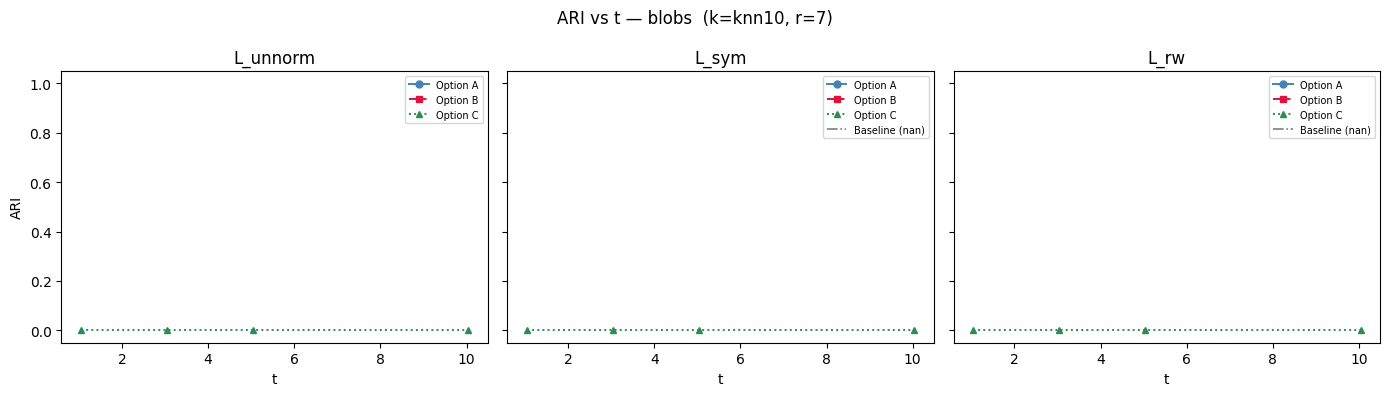

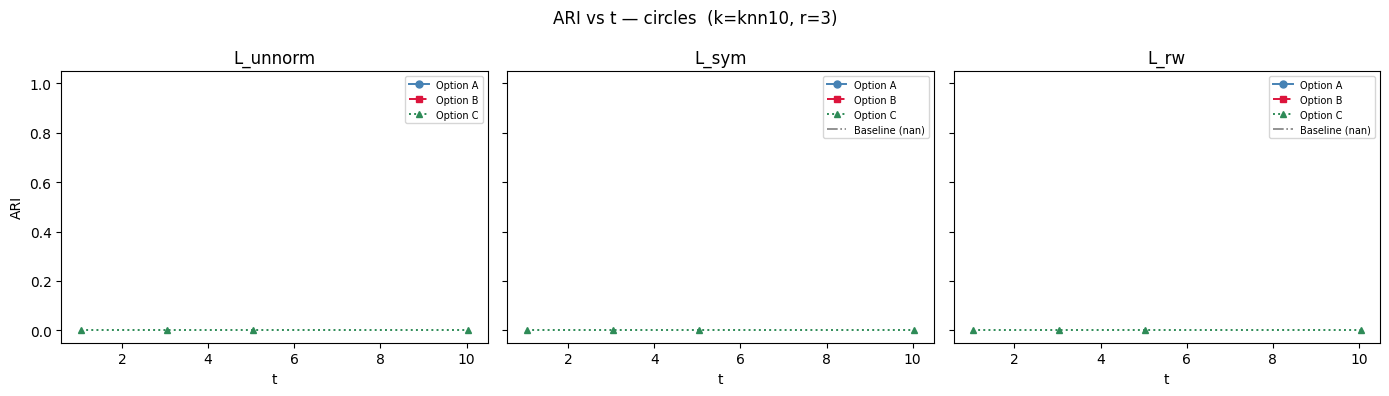

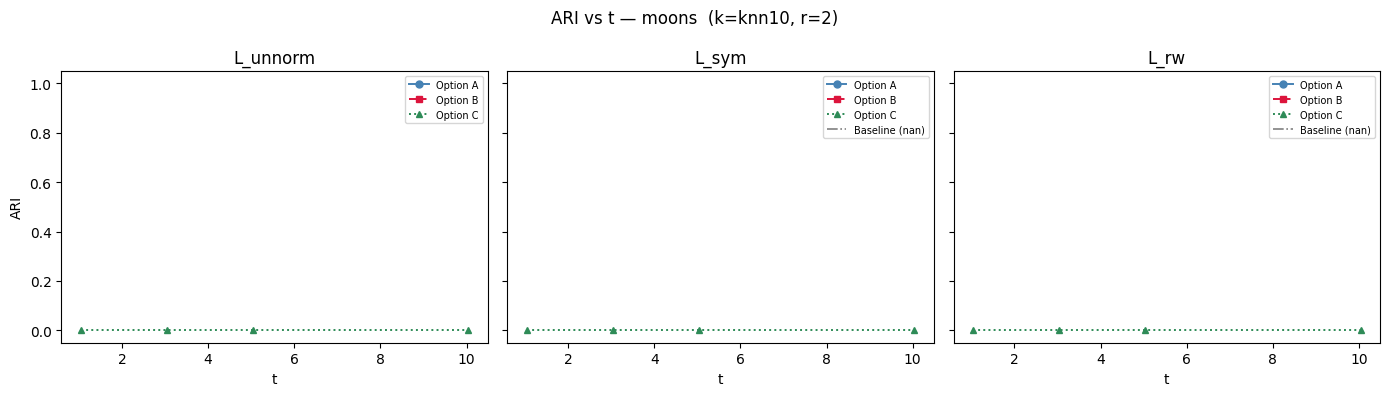

In [11]:
# Plot 1 — ARI vs t for each option (one figure per dataset)
# Fixed: k-NN value, r = n_clusters (canonical rank)
# Overlapping lines are distinguished by colour + linestyle + marker.

method_styles = {
    "option_a": dict(color="steelblue", linestyle="-",  marker="o", label="Option A"),
    "option_b": dict(color="crimson",   linestyle="--", marker="s", label="Option B"),
    "option_c": dict(color="seagreen",  linestyle=":",  marker="^", label="Option C"),
}

for ds in dataset_registry:
    name  = ds["name"]
    r_can = ds["n_clusters"]
    k_nn  = f"knn{[v for v in ds['k_values'] if v < len(ds['X']) - 1][0]}"

    fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)
    fig.suptitle(f"ARI vs t — {name}  (k={k_nn}, r={r_can})", fontsize=12)

    for ax, lap in zip(axes, ["unnorm", "sym", "rw"]):
        sub = df[(df.dataset == name) & (df.k == k_nn) & (df.lap == lap)]

        t_vals = sorted(sub["t"].dropna().unique())
        # Small x-offset per method so markers don't overlap exactly
        offsets = {"option_a": -0.04, "option_b": 0.0, "option_c": 0.04}

        for method, style in method_styles.items():
            if method == "option_c":
                pts = sub[sub.method == method].groupby("t")["ari"].mean()
            else:
                pts = sub[(sub.method == method) & (sub.r == r_can)].groupby("t")["ari"].mean()

            if pts.empty:
                continue

            x = pts.index.to_numpy() + offsets[method]
            ax.plot(x, pts.values, markersize=5, linewidth=1.4,
                    zorder=3, **style)

        # Baseline — horizontal dashed line
        bl = df[(df.dataset == name) & (df.method == "baseline") &
                (df.k == k_nn) & (df.lap == lap) & (df.r == r_can)]["ari"]
        if len(bl):
            ax.axhline(bl.mean(), color="grey", linestyle="-.", linewidth=1.2,
                       label=f"Baseline ({bl.mean():.2f})", zorder=2)

        ax.set_title(f"L_{lap}")
        ax.set_xlabel("t")
        ax.set_ylim(-0.05, 1.05)
        if ax is axes[0]:
            ax.set_ylabel("ARI")
        ax.legend(fontsize=7)

    plt.tight_layout()
    plt.show()


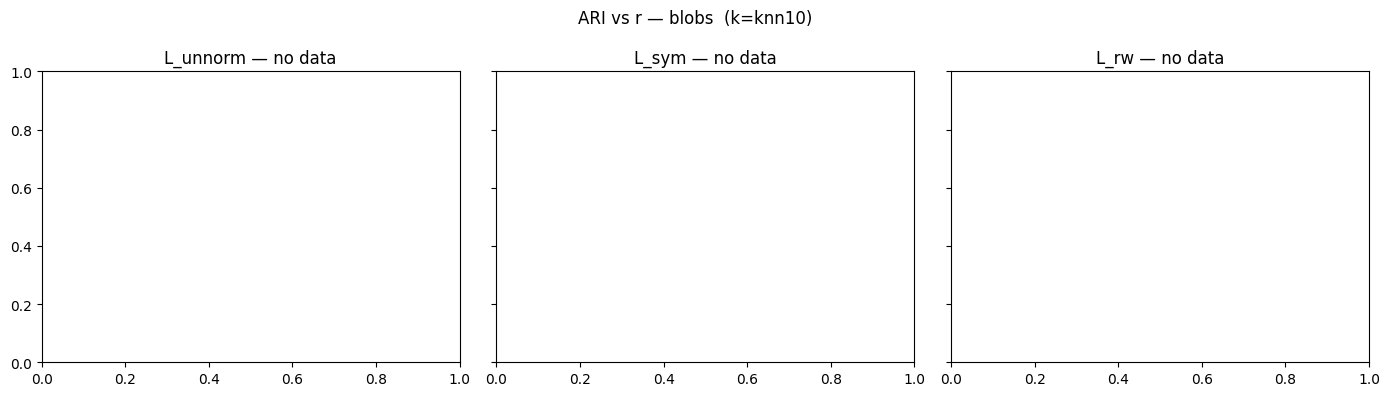

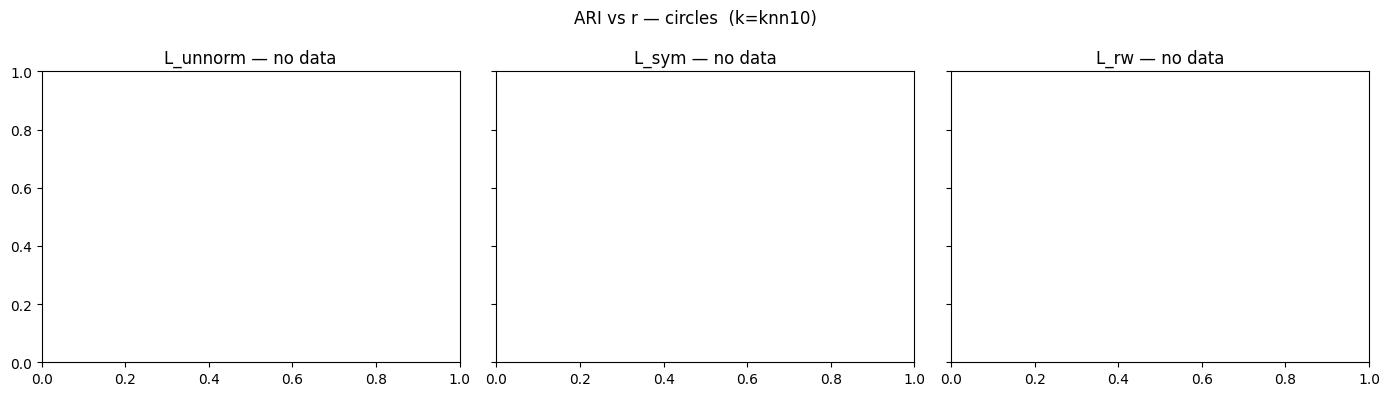

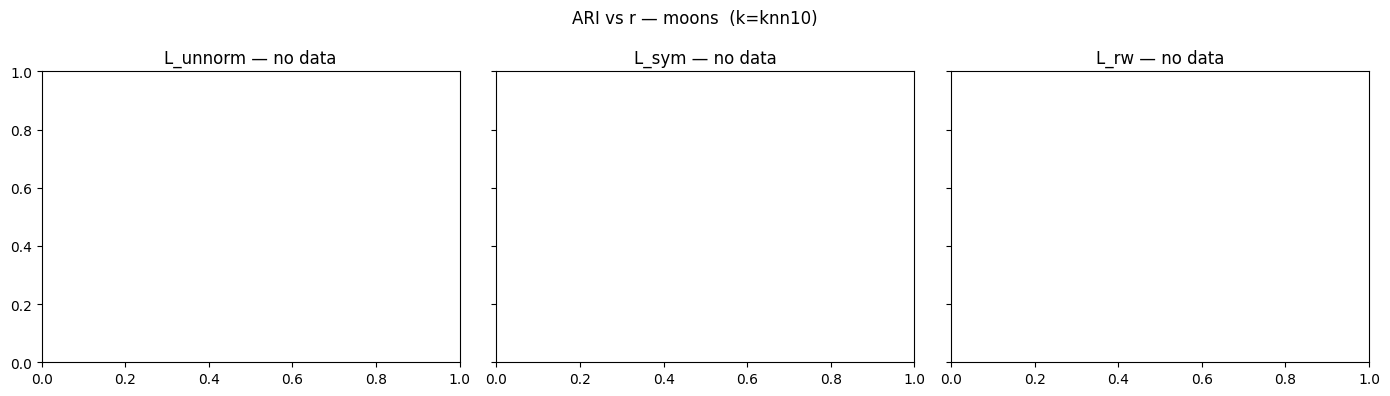

In [12]:
# Plot 2 — ARI vs r for Options A and B
# Fixed: k-NN value, best t from Plot 1 (highest mean ARI across A+B)

for ds in dataset_registry:
    name   = ds["name"]
    k_nn   = f"knn{[v for v in ds['k_values'] if v < len(ds['X']) - 1][0]}"
    r_vals = ds["r_values"]

    fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)
    fig.suptitle(f"ARI vs r — {name}  (k={k_nn})", fontsize=12)

    for ax, lap in zip(axes, ["unnorm", "sym", "rw"]):
        sub = df[(df.dataset == name) & (df.k == k_nn) & (df.lap == lap)]

        # Find best t: highest mean ARI across A and B
        ab = sub[sub.method.isin(["option_a", "option_b"])]
        if ab.empty or ab["ari"].isna().all():
            ax.set_title(f"L_{lap} — no data")
            continue
        best_t = ab.groupby("t")["ari"].mean().idxmax()

        for method, style in [("option_a", dict(color="steelblue", label=f"Option A (t={best_t})")),
                               ("option_b", dict(color="crimson",   label=f"Option B (t={best_t})"))]:
            pts = sub[(sub.method == method) & (sub.t == best_t)].groupby("r")["ari"].mean()
            ax.plot(pts.index, pts.values, "o-", **style)

        # Baseline
        bl_pts = df[(df.dataset == name) & (df.method == "baseline") &
                    (df.k == k_nn) & (df.lap == lap)].groupby("r")["ari"].mean()
        ax.plot(bl_pts.index, bl_pts.values, "s--", color="grey", label="Baseline")

        ax.set_title(f"L_{lap}")
        ax.set_xlabel("r")
        if ax == axes[0]:
            ax.set_ylabel("ARI")
        ax.set_ylim(-0.05, 1.05)
        ax.legend(fontsize=7)

    plt.tight_layout()
    plt.show()


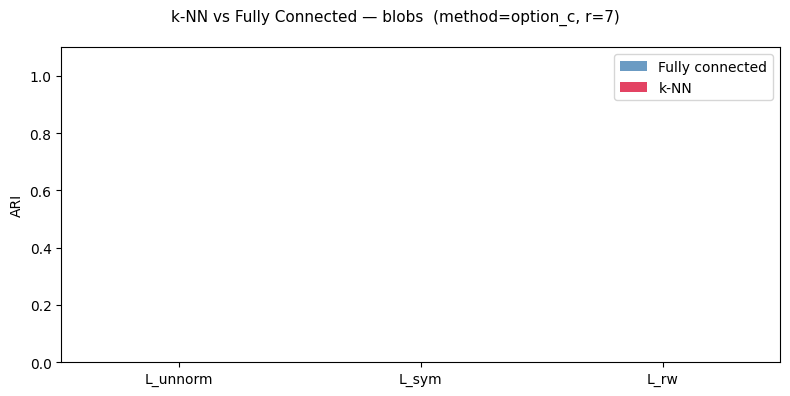

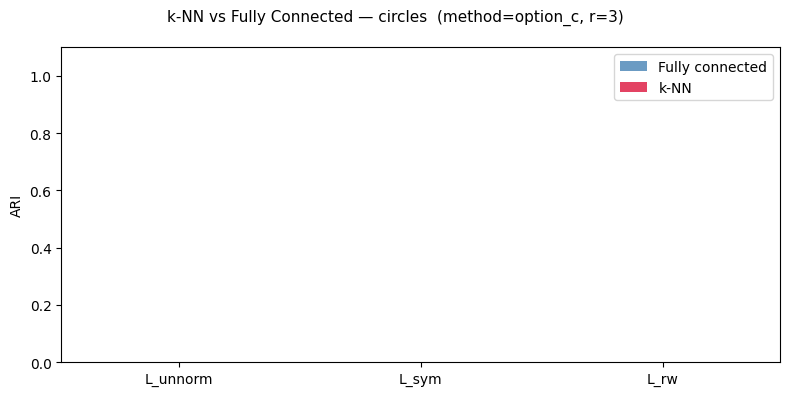

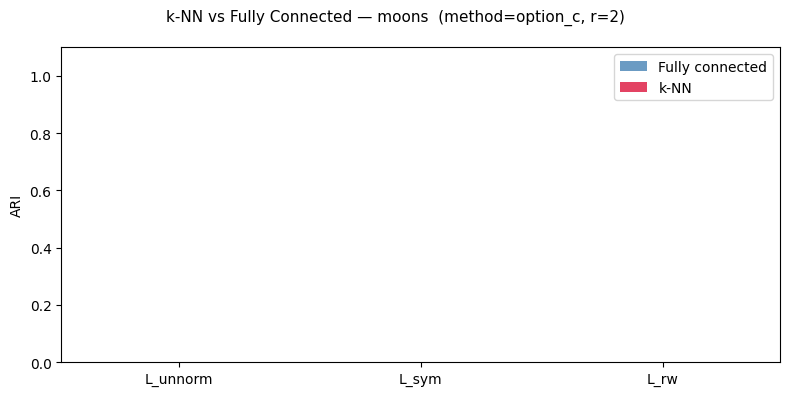

In [13]:
# Plot 3 — k-NN vs fully connected, best option, grouped by Laplacian

for ds in dataset_registry:
    name   = ds["name"]
    r_can  = ds["n_clusters"]
    k_full = "full"
    k_nn   = f"knn{[v for v in ds['k_values'] if v < len(ds['X']) - 1][0]}"

    # Identify the best-performing option overall
    sub_all = df[(df.dataset == name) & (df.r.isin([r_can, np.nan]))]
    best_method = sub_all.groupby("method")["ari"].mean().idxmax()

    fig, ax = plt.subplots(figsize=(8, 4))
    fig.suptitle(f"k-NN vs Fully Connected — {name}  (method={best_method}, r={r_can})", fontsize=11)

    laps = ["unnorm", "sym", "rw"]
    x    = np.arange(len(laps))
    w    = 0.35

    for shift, k_label, colour, label in [
        (-w/2, k_full, "steelblue", "Fully connected"),
        ( w/2, k_nn,   "crimson",   "k-NN"),
    ]:
        aris = []
        for lap in laps:
            sub = df[(df.dataset == name) & (df.method == best_method) &
                     (df.k == k_label) & (df.lap == lap)]
            if not sub.empty and not sub["ari"].isna().all():
                best_t = sub.groupby("t")["ari"].mean().idxmax() if "t" in sub.columns and sub["t"].notna().any() else 0
                val = sub[sub.t == best_t]["ari"].mean() if best_t else sub["ari"].mean()
            else:
                val = 0
            aris.append(val)
        ax.bar(x + shift, aris, width=w, color=colour, label=label, alpha=0.8)

    ax.set_xticks(x)
    ax.set_xticklabels([f"L_{l}" for l in laps])
    ax.set_ylabel("ARI")
    ax.set_ylim(0, 1.1)
    ax.legend()
    plt.tight_layout()
    plt.show()


In [14]:
# Plot 4 — Embedding visualisation for moons (2×2 grid)

ds      = dataset_registry[2]  # moons
X, y    = ds["X"], ds["y"]
sigma   = ds["sigma"]
k_nn    = [v for v in ds["k_values"] if v < len(X) - 1][0]
r_vis   = 2

# Find best Laplacian and t from results
sub_moons = df[(df.dataset == "moons") & (df.k == f"knn{k_nn}")]
best_lap  = sub_moons.groupby("lap")["ari"].mean().idxmax()
best_t    = sub_moons[sub_moons.method.isin(["option_a","option_b"])].groupby("t")["ari"].mean().idxmax()

print(f"Moons visualisation: best_lap={best_lap}, best_t={best_t}, k={k_nn}, r={r_vis}")

D_mat = dist_mat(X)
A     = knn_affinity(D_mat, k=k_nn, sigma=sigma)
L, _  = build_laplacian(A, best_lap)
K_t, eig_vals_kt, eig_vecs_kt = compute_diffusion_kernel(L, best_t, best_lap)

colours = [plt.cm.tab10(i) for i in range(len(np.unique(y)))]
def _scatter(ax, Y, y_true, title):
    for i, lbl in enumerate(np.unique(y_true)):
        ax.scatter(Y[y_true == lbl, 0], Y[y_true == lbl, 1],
                   c=[colours[i]], s=12, alpha=0.5)
    ax.set_title(title, fontsize=9)

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
fig.suptitle(f"Moons embeddings — L_{best_lap}, t={best_t}, k={k_nn}", fontsize=11)

# Top-left: baseline
eig_vals_b, eig_vecs_b = scipy.linalg.eigh(L) if best_lap in ("unnorm","sym") else (None, None)
if eig_vals_b is not None:
    U_bl = eig_vecs_b[:, :r_vis]
    if best_lap == "sym":
        U_bl = U_bl / np.maximum(np.linalg.norm(U_bl, axis=1, keepdims=True), 1e-12)
    _scatter(axes[0, 0], U_bl, y, "Baseline (no diffusion)")

# Top-right: Option A
D_new = np.diag(K_t.sum(axis=1))
L_new = D_new - (K_t + K_t.T) / 2
_, ev_a = scipy.linalg.eigh(L_new)
_scatter(axes[0, 1], ev_a[:, :r_vis], y, f"Option A (t={best_t})")

# Bottom-left: Option B
weights = np.exp(-best_t * eig_vals_kt[:r_vis]) if best_lap in ("unnorm","sym") else np.ones(r_vis)
U_b = eig_vecs_kt[:, :r_vis] * weights[np.newaxis, :]
_scatter(axes[1, 0], U_b, y, f"Option B (t={best_t})")

# Bottom-right: first 2 eigenvectors of K_t (what Option A works with)
_, ev_kt = scipy.linalg.eigh((K_t + K_t.T) / 2)
_scatter(axes[1, 1], ev_kt[:, -r_vis:], y, "K_t eigenvectors (Option A input)")

plt.tight_layout()
plt.show()


ValueError: Encountered all NA values

---
## Section 7 — Summary

In [ ]:
for ds in dataset_registry:
    name   = ds["name"]
    n_true = ds["n_clusters"]
    sub    = df[df.dataset == name].copy()

    rows = []
    for method in ["baseline", "option_a", "option_b", "option_c"]:
        msub = sub[sub.method == method]
        if msub.empty or msub["ari"].isna().all():
            continue
        # Find the row with highest ARI across all parameters
        best = msub.loc[msub["ari"].idxmax()]
        rows.append({
            "method":    method,
            "lap":       best["lap"],
            "k":         best["k"],
            "best_t":    best["t"],
            "best_r":    best["r"],
            "best_ARI":  round(best["ari"], 3),
            "n_found":   best["n_found"],
        })

    summary = pd.DataFrame(rows)
    print(f"\n{'='*60}")
    print(f"Summary — {name}  (true k = {n_true})")
    print(f"{'='*60}")
    print(summary.to_string(index=False))


---
## Interpretation

*Fill in after running the experiment.*

**Q1 — Which option (A, B, or C) performs best overall?**

> 

**Q2 — Which Laplacian type works best with the diffusion kernel?**

> 

**Q3 — Does the unnormalised Laplacian offer any advantage when used with the diffusion kernel?**

> 

**Q4 — For the best-performing option, does k-NN sparsification still matter, or does the diffusion kernel compensate for a fully connected graph?**

> 

**Q5 — Are there numerical issues with L_rw? At what t values do they appear?**

> 